In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

d = pd.read_csv('../data/data PM10 mean 2025.csv', sep=";")

# Filtrer la France métropolitaine
d_metro = d[
    (d["validité"] == 1) &
    (d["Latitude"].between(41.0, 51.5)) &
    (d["Longitude"].between(-5.5, 10.0))
].dropna(subset=["Latitude", "Longitude", "valeur"])

import requests
import geopandas as gpd

# Altitude via API open-elevation (gratuit)
def get_altitude(lat, lon):
    url = f"https://api.open-elevation.com/api/v1/lookup?locations={lat},{lon}"
    r = requests.get(url)
    return r.json()['results'][0]['elevation']

d_metro['altitude'] = d_metro.apply(lambda row: get_altitude(row['Latitude'], row['Longitude']), axis=1)



In [16]:
import time

def get_population(lat, lon):
    try:
        url = f"https://geo.api.gouv.fr/communes?lat={lat}&lon={lon}&fields=nom,population&format=json"
        r = requests.get(url, timeout=10)
        data = r.json()
        if data:
            return data[0].get('population', None)
    except:
        return None

print("Récupération population INSEE...")
d_metro['population'] = None
for i, row in d_metro.iterrows():
    d_metro.at[i, 'population'] = get_population(row['Latitude'], row['Longitude'])
    time.sleep(0.2)

print("Done !")
print(d_metro['population'].head())

Récupération population INSEE...
Done !
0    122572
1    122572
2     14190
3     42658
4     15806
Name: population, dtype: object


In [23]:
def get_meteo(lat, lon):
    try:
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": lat,
            "longitude": lon,
            "start_date": "2025-01-01",
            "end_date": "2025-12-31",
            "daily": ["wind_speed_10m_max", "precipitation_sum", "temperature_2m_mean"],
            "timezone": "Europe/Paris"
        }
        r = requests.get(url, params=params, timeout=15)
        data = r.json()['daily']
        return {
            'vent_moyen': pd.Series(data['wind_speed_10m_max']).mean(),
            'precipitation_annuelle': pd.Series(data['precipitation_sum']).sum(),
            'temperature_moyenne': pd.Series(data['temperature_2m_mean']).mean()
        }
    except:
        return {'vent_moyen': None, 'precipitation_annuelle': None, 'temperature_moyenne': None}

print("Récupération météo...")
meteo_data = []
for _, row in d_metro.iterrows():
    meteo_data.append(get_meteo(row['Latitude'], row['Longitude']))
    time.sleep(0.3)

meteo_df = pd.DataFrame(meteo_data)
d_metro['vent_moyen'] = meteo_df['vent_moyen'].values
d_metro['precipitation_annuelle'] = meteo_df['precipitation_annuelle'].values
d_metro['temperature_moyenne'] = meteo_df['temperature_moyenne'].values

print("Done !")


Récupération météo...
Done !


In [30]:
mask = d_metro['vent_moyen'].isnull()

print(f"{mask.sum()} lignes à récupérer...")

for i, row in d_metro[mask].iterrows():
    result = get_meteo(row['Latitude'], row['Longitude'])
    d_metro.at[i, 'vent_moyen'] = result['vent_moyen']
    d_metro.at[i, 'precipitation_annuelle'] = result['precipitation_annuelle']
    d_metro.at[i, 'temperature_moyenne'] = result['temperature_moyenne']
    time.sleep(0.5)

print(f"NaN restants : {d_metro['vent_moyen'].isnull().sum()}")

47 lignes à récupérer...
NaN restants : 0


In [ ]:
def get_icpe(lat, lon, rayon=5000):
    try:
        url = "https://georisques.gouv.fr/api/v1/installations_classees"
        params = {
            "latlon": f"{lon},{lat}",
            "rayon": rayon,
            "page": 1,
            "page_size": 1
        }
        r = requests.get(url, params=params, timeout=15)
        data = r.json()
        return data.get('results', 0)
    except:
        return None

print("Récupération ICPE...")
d_metro['nb_icpe'] = None
for i, row in d_metro.iterrows():
    d_metro.at[i, 'nb_icpe'] = get_icpe(row['Latitude'], row['Longitude'])
    time.sleep(0.3)

print("Done !")


Récupération ICPE...
Done !
                nom site nb_icpe
34      Place de l'Opéra    1457
37   Boulevard Haussmann    1410
24           PARIS 18eme    1343
25    Place Victor Basch    1053
45  Bld peripherique Est    1002
30  Auto A1 -Saint-Denis     922
23         GENNEVILLIERS     819
38               BOBIGNY     695
27       VITRY-SUR-SEINE     643
41   PARIS Stade Lenglen     621


In [42]:
# print(d_metro[['nom site', 'population']].sort_values('population', ascending=False).head(20))
# print(d_metro[['nom site', 'vent_moyen', 'precipitation_annuelle', 'temperature_moyenne']].head())
print(d_metro[['nom site', 'nb_icpe']].sort_values('nb_icpe', ascending=False).head(10))

                nom site nb_icpe
34      Place de l'Opéra    1457
37   Boulevard Haussmann    1410
24           PARIS 18eme    1343
25    Place Victor Basch    1053
45  Bld peripherique Est    1002
30  Auto A1 -Saint-Denis     922
23         GENNEVILLIERS     819
38               BOBIGNY     695
27       VITRY-SUR-SEINE     643
41   PARIS Stade Lenglen     621


# SAR

In [4]:
print(d_metro["type d'implantation"].value_counts())
print()
print(d_metro["type d'influence"].value_counts())

type d'implantation
Urbaine                   211
Périurbaine                51
Rurale régionale           15
Rurale près des villes     12
Rurale nationale            9
Name: count, dtype: int64

type d'influence
Fond            203
Trafic           62
Industrielle     33
Name: count, dtype: int64


In [43]:
import libpysal
from spreg import ML_Lag
from sklearn.preprocessing import StandardScaler

# Encodage des variables qualitatives
d_sar = d_metro.copy()

implantation_dummies = pd.get_dummies(d_sar["type d'implantation"], drop_first=True).astype(int)
influence_dummies = pd.get_dummies(d_sar["type d'influence"], drop_first=True).astype(int)

d_sar = pd.concat([d_sar, implantation_dummies, influence_dummies], axis=1)

# Variable dépendante et covariables
noms = implantation_dummies.columns.tolist() + influence_dummies.columns.tolist()

# Ajout des nouvelles variables dont nb_icpe
noms_continus = ['altitude', 'population', 'vent_moyen', 'precipitation_annuelle', 'temperature_moyenne', 'nb_icpe']

# Normalisation des variables continues
scaler = StandardScaler()
d_sar[noms_continus] = scaler.fit_transform(d_sar[noms_continus])

noms_all = noms + noms_continus

y = d_sar["valeur brute"].values.reshape(-1, 1)
X = d_sar[noms_all].values

# Matrice de voisinage
coords_sar = list(zip(d_sar["Longitude"], d_sar["Latitude"]))
W = libpysal.weights.KNN.from_array(np.array(coords_sar), k=8)
W.transform = "r"

# Modèle SAR
sar = ML_Lag(y, X, W, name_y="PM10", name_x=noms_all)
print(sar.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :        PM10                Number of Observations:         298
Mean dependent var  :     15.1084                Number of Variables   :          14
S.D. dependent var  :      3.3391                Degrees of Freedom    :         284
Pseudo R-squared    :      0.5673
Spatial Pseudo R-squared:  0.4690
Log likelihood      :   -659.9080
Sigma-square ML     :      4.8103                Akaike info criterion :    1347.816
S.E of regression   :      2.1932                Schwarz criterion     :    1399.575

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------

# SEM

In [44]:
from spreg import ML_Error

# Modèle SEM
sem = ML_Error(y, X, W, name_y="PM10", name_x=noms_all)
print(sem.summary)

ML_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :        PM10                Number of Observations:         298
Mean dependent var  :     15.1084                Number of Variables   :          13
S.D. dependent var  :      3.3391                Degrees of Freedom    :         285
Pseudo R-squared    :      0.4966
Log likelihood      :   -648.8903
Sigma-square ML     :      4.3456                Akaike info criterion :    1323.781
S.E of regression   :      2.0846                Schwarz criterion     :    1371.843

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------------------------------------

C:\Users\jerem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


# Test Lagrange

In [37]:
from spreg import OLS
from libpysal.weights import lag_spatial

# OLS de base
ols = OLS(y, X, W, name_y="PM10", name_x=noms_all, spat_diag=True)
print(ols.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :        PM10                Number of Observations:         298
Mean dependent var  :     15.1084                Number of Variables   :          12
S.D. dependent var  :      3.3391                Degrees of Freedom    :         286
R-squared           :      0.4788
Adjusted R-squared  :      0.4588
Sum squared residual:     1725.96                F-statistic           :     23.8847
Sigma-square        :       6.035                Prob(F-statistic)     :   1.333e-34
S.E. of regression  :       2.457                Log likelihood        :    -684.554
Sigma-square ML     :       5.792                Akaike info criterion :    1393.109
S.E of regression ML:      2.4066                Schwarz criterion     :    1437.474

-----------------

# Indice Moran

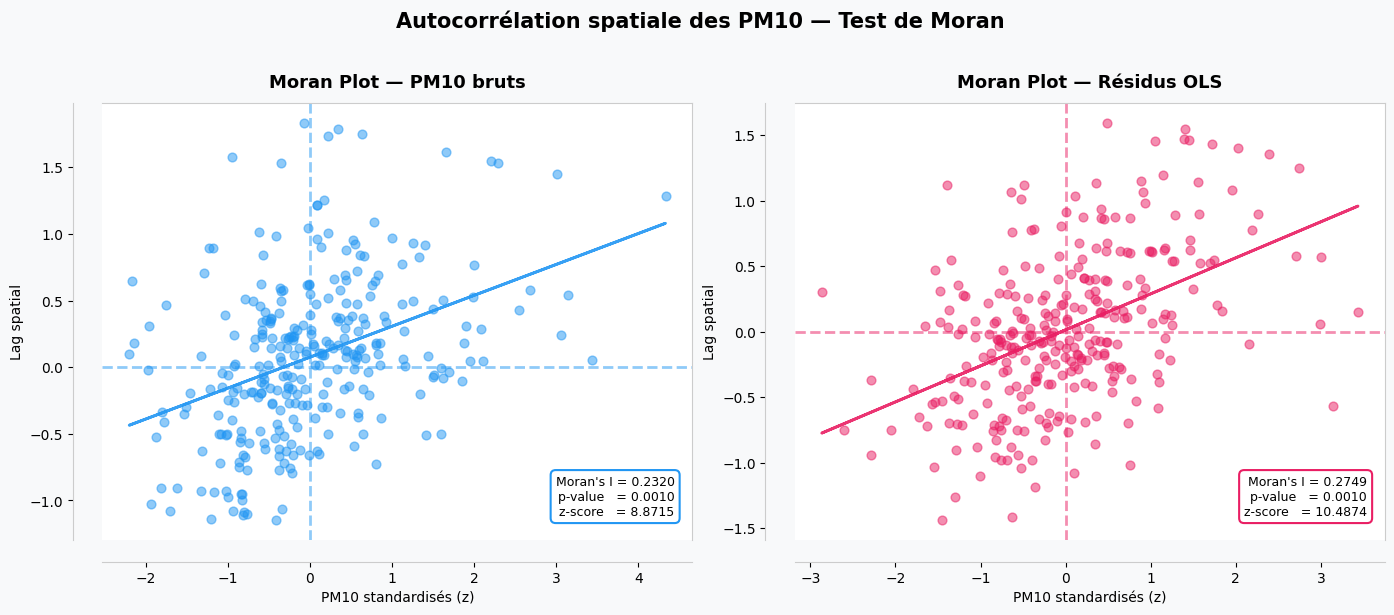


Moran's I (PM10 bruts)  : 0.2320 | p-value : 0.0010
Moran's I (résidus OLS) : 0.2749 | p-value : 0.0010


In [ ]:
from esda.moran import Moran
from splot.esda import moran_scatterplot
import matplotlib.pyplot as plt

# ============================================================
# CALCUL DES MORAN
# ============================================================

moran_y = Moran(y, W)
ols_model = OLS(y, X, W, name_y="PM10", name_x=noms_all, spat_diag=True)
residus = ols_model.u
moran_resid = Moran(residus, W)

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#f8f9fa')

for ax, moran_obj, title, color in [
    (axes[0], moran_y,     "PM10 bruts",  "#2196F3"),
    (axes[1], moran_resid, "Résidus OLS", "#E91E63")
]:
    moran_scatterplot(moran_obj, ax=ax, aspect_equal=False)

    # Recolorer les points
    for collection in ax.collections:
        collection.set_color(color)
        collection.set_alpha(0.5)

    # Recolorer la ligne
    for line in ax.lines:
        line.set_color(color)
        line.set_linewidth(2)

    # Encadré statistiques
    stats_text = (
        f"Moran's I = {moran_obj.I:.4f}\n"
        f"p-value   = {moran_obj.p_sim:.4f}\n"
        f"z-score   = {moran_obj.z_norm:.4f}"
    )
    ax.text(0.97, 0.05, stats_text,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='bottom',
            horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=color, linewidth=1.5))

    ax.set_facecolor('white')
    ax.set_title(f"Moran Plot — {title}", fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("PM10 standardisés (z)", fontsize=10)
    ax.set_ylabel("Lag spatial", fontsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')

fig.suptitle("Autocorrélation spatiale des PM10 — Test de Moran",
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print(f"\nMoran's I (PM10 bruts)  : {moran_y.I:.4f} | p-value : {moran_y.p_sim:.4f}")
print(f"Moran's I (résidus OLS) : {moran_resid.I:.4f} | p-value : {moran_resid.p_sim:.4f}")